# Проверка src/draftslice/core/pipeline.py

Сначала прогон готовой библиотечной функции `slice_drawing_into_regions` по всему датасету `data/images`, затем ниже - разбор по шагам на одном выбранном файле, через отдельные функции core.

In [1]:
from pathlib import Path

import ipywidgets as widgets
import numpy as np
from IPython.display import display
from matplotlib import pyplot as plt

from draftslice.core.io import load_image
from draftslice.core.region_segmentation.comp_classification import classify_components
from draftslice.core.region_segmentation.comp_labeling import find_connected_components
from draftslice.core.region_segmentation.pipeline import RegionCrop, extract_region_crops, run
from draftslice.core.region_segmentation.preprocess import preprocess_drawing
from draftslice.core.region_segmentation.region_grouping import group_regions
from draftslice.core.region_segmentation.region_merging import merge_into_chunks
from draftslice.core.types import Mat


In [2]:
files = sorted(Path("../data/images").glob("*.jpg"))

## Прогон по всему датасету

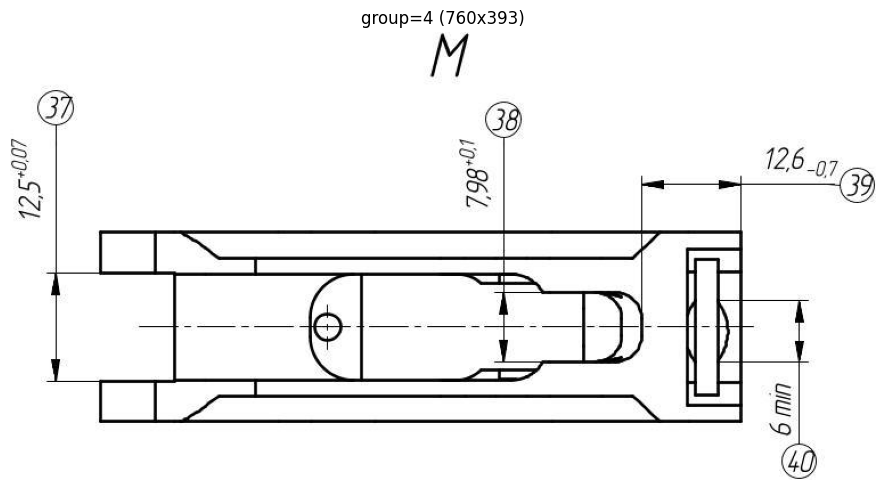

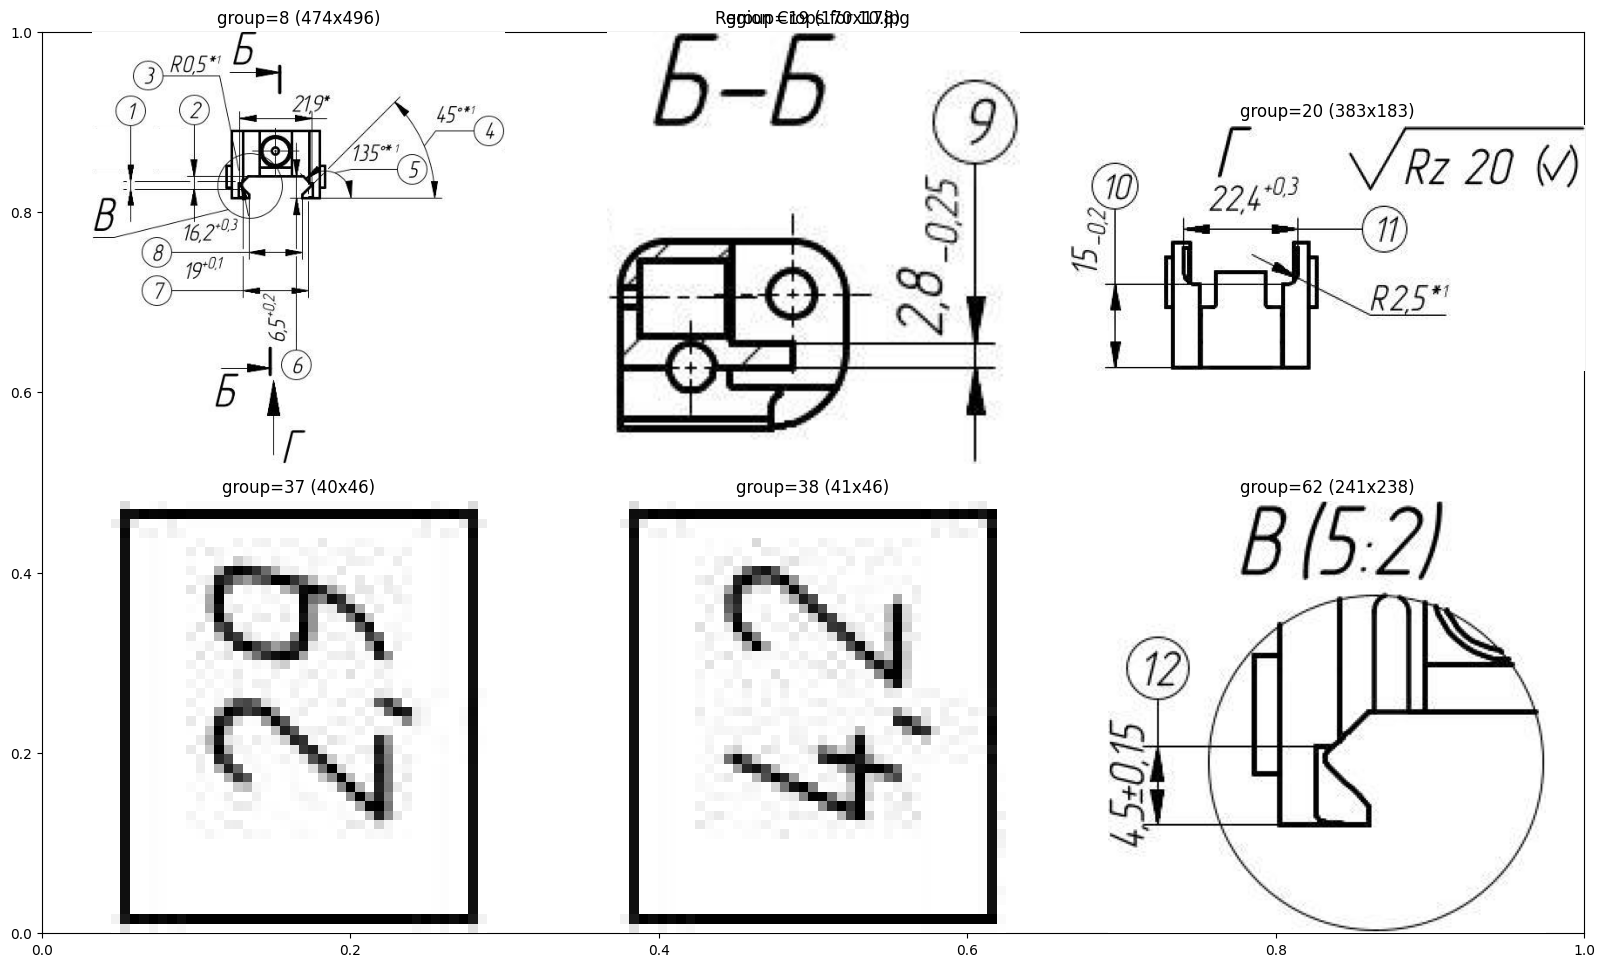

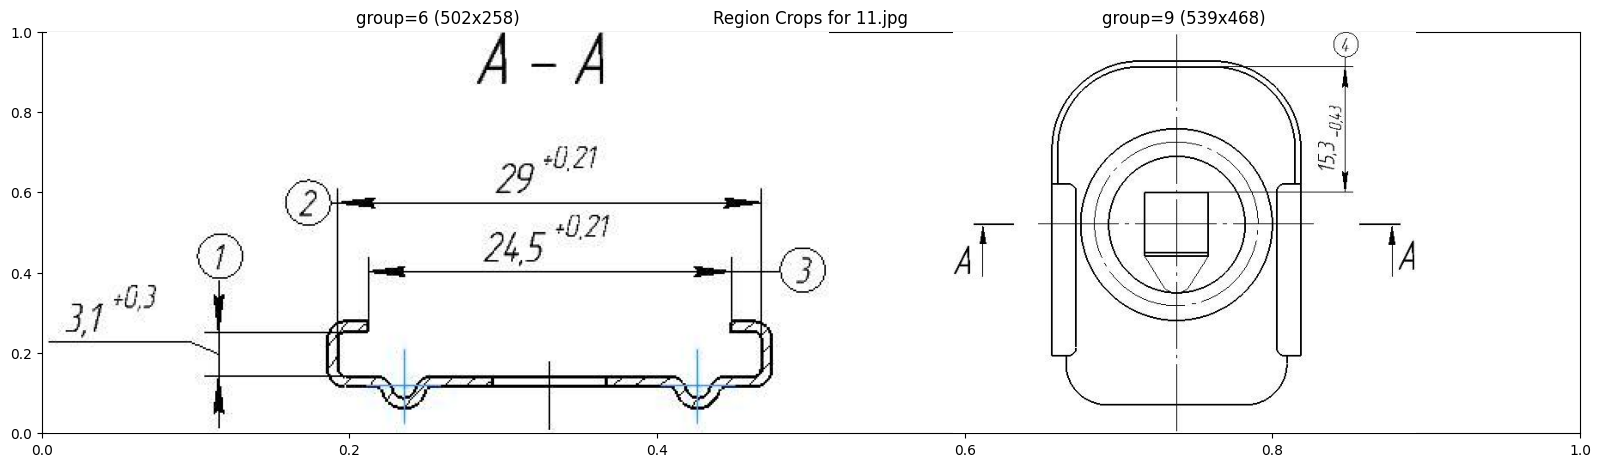

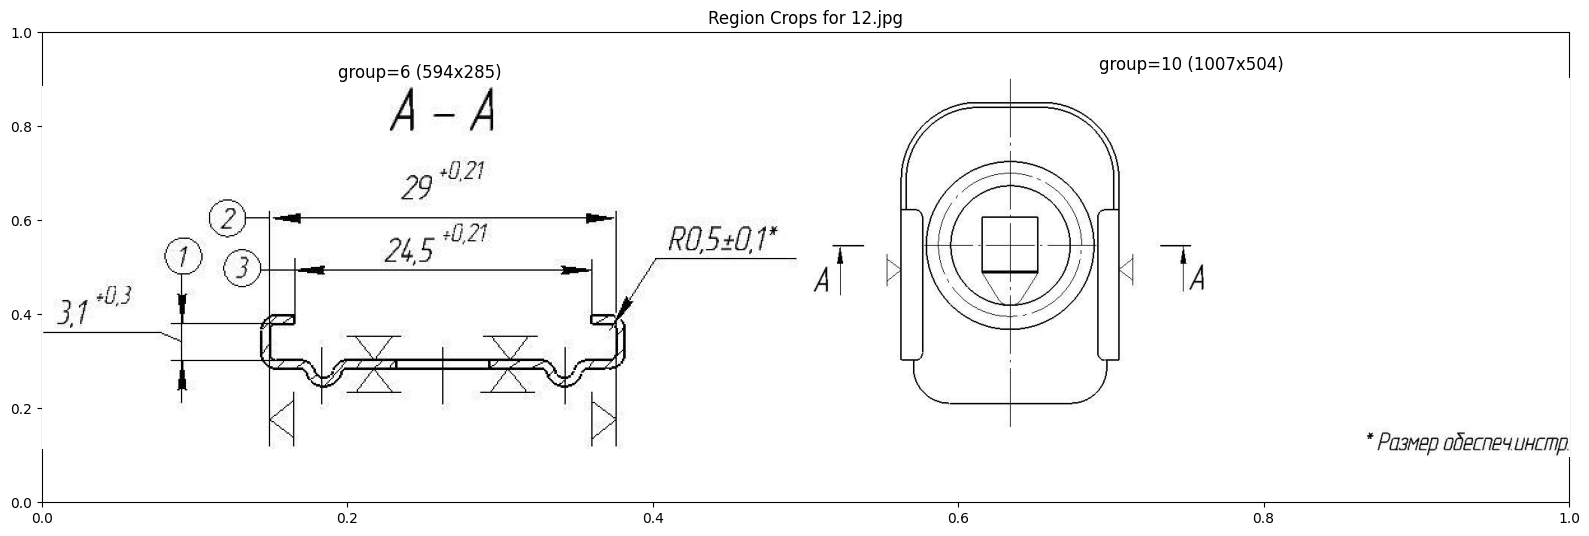

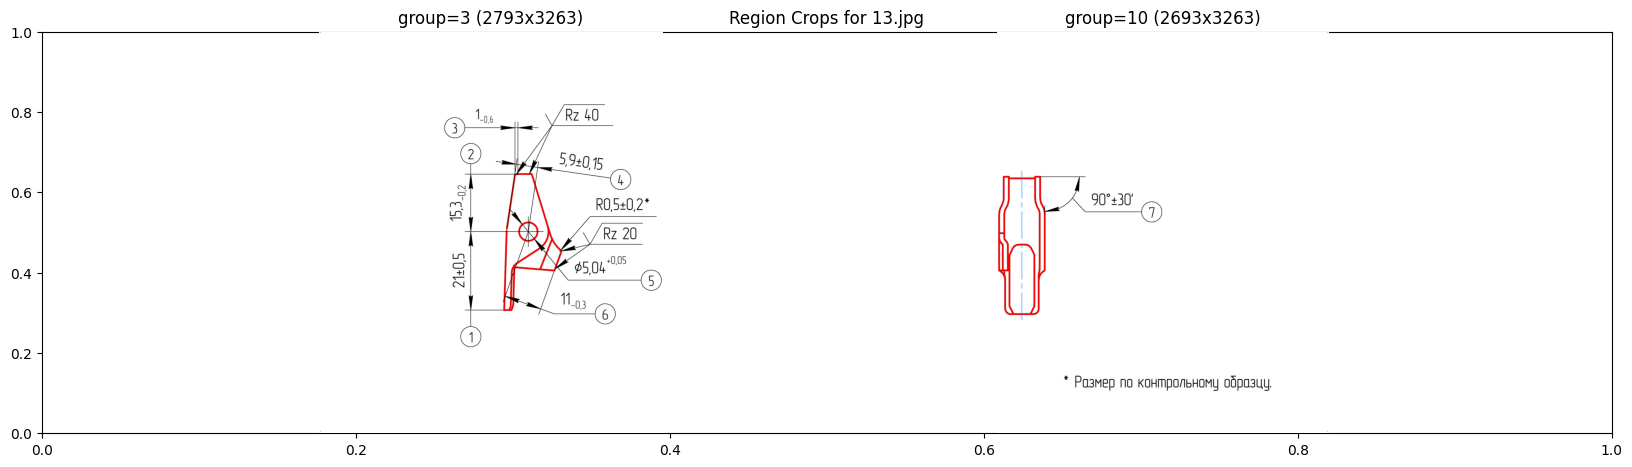

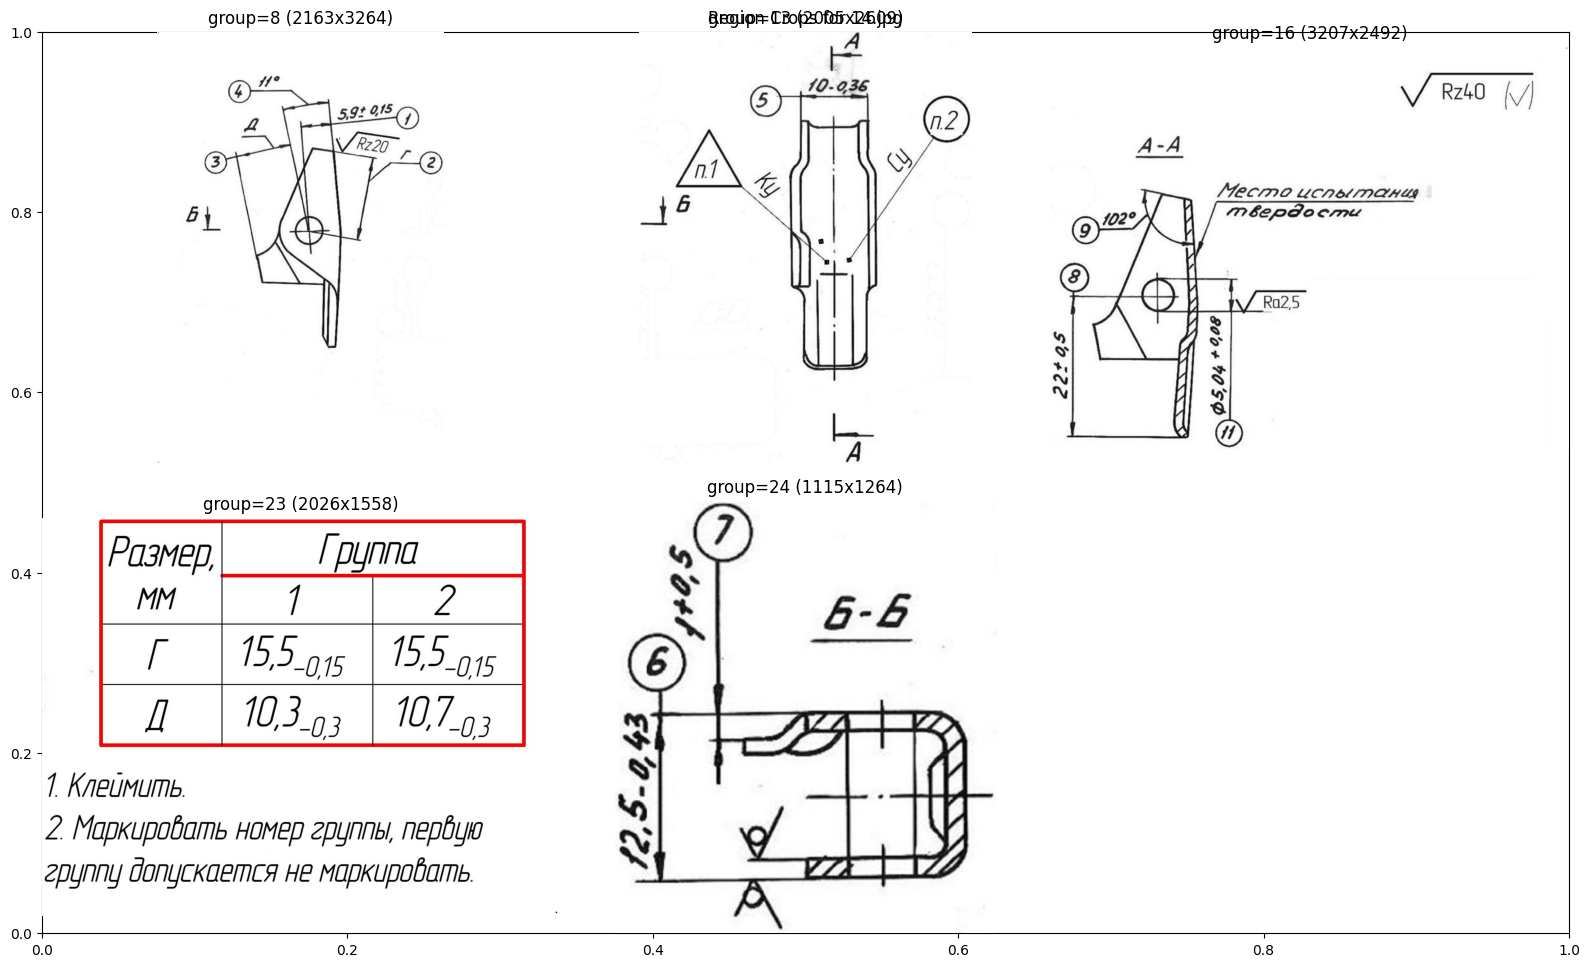

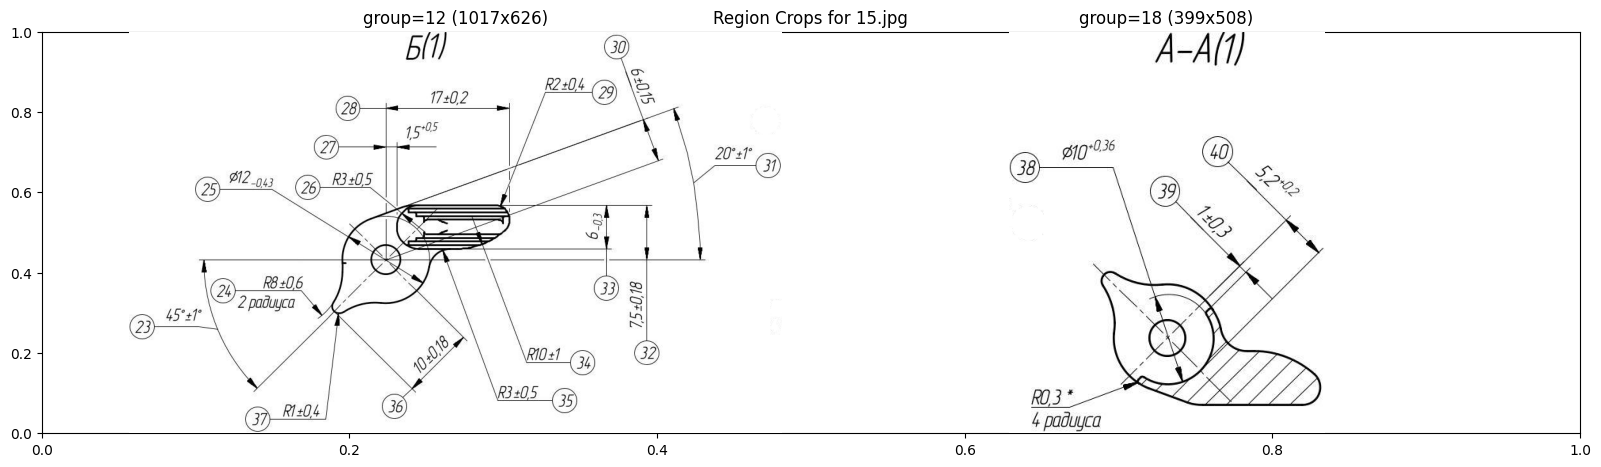

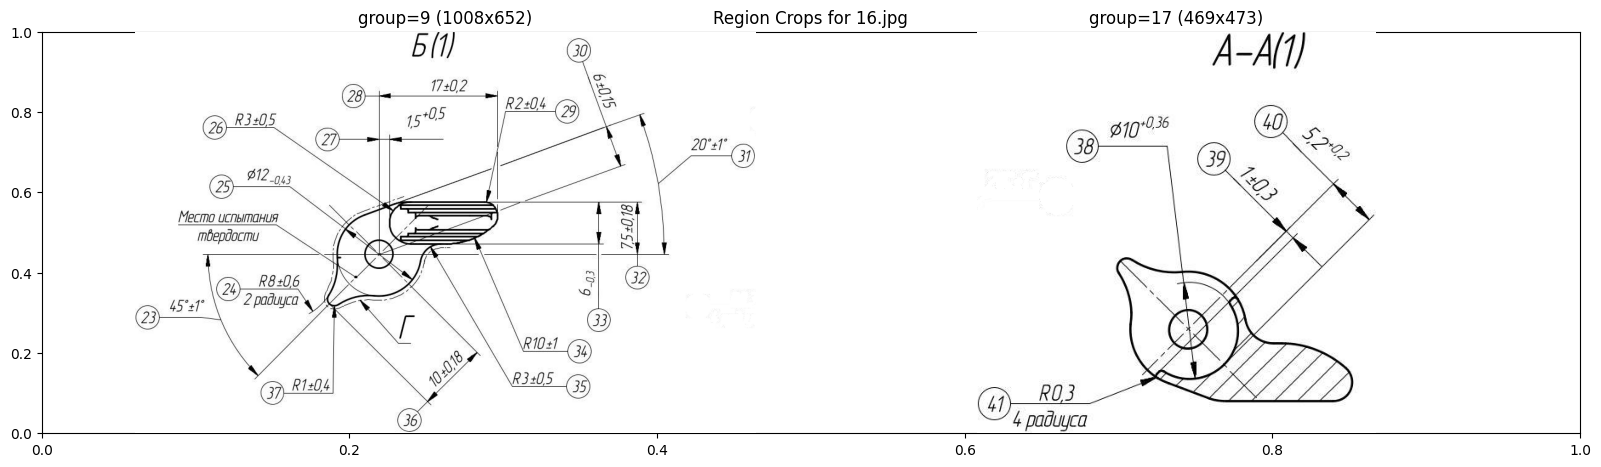

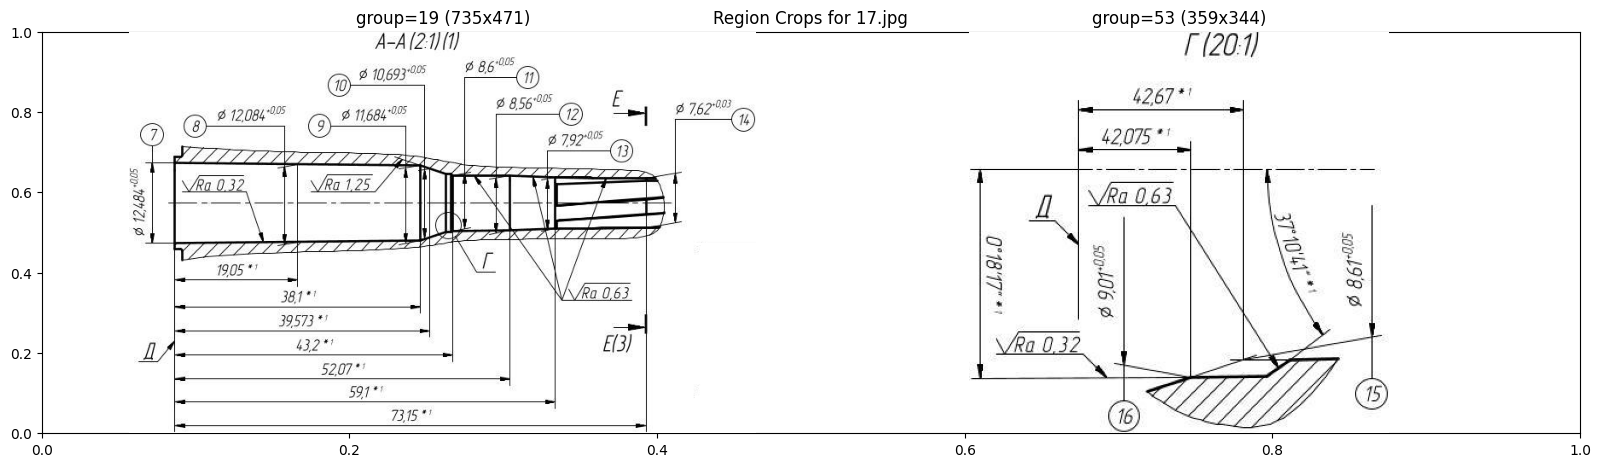

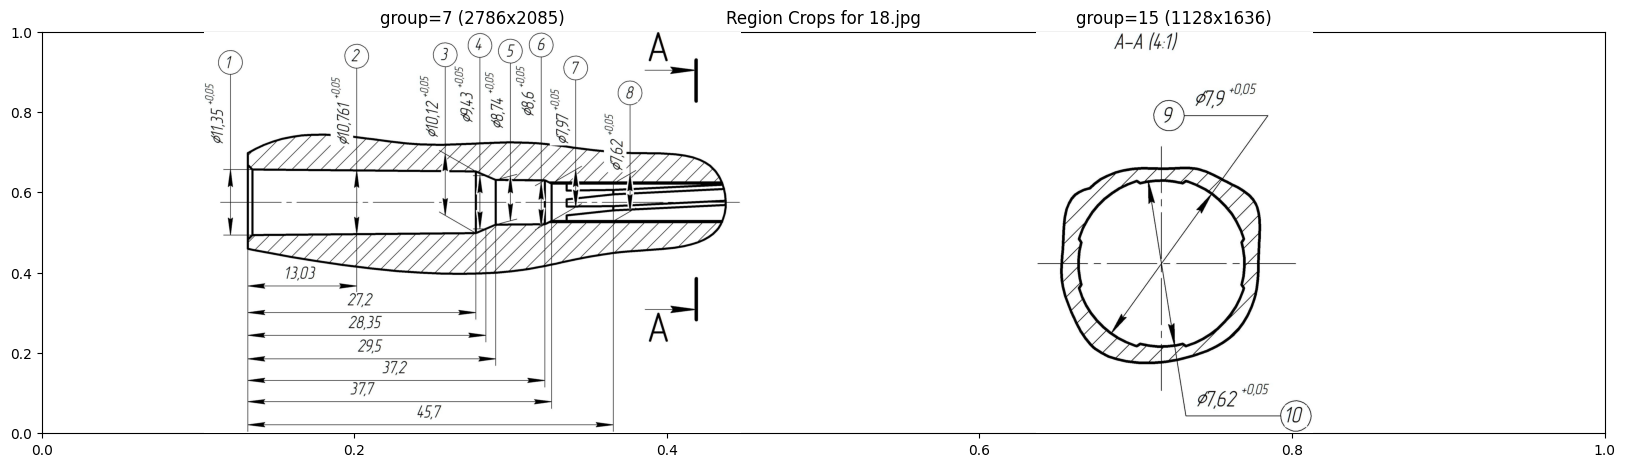

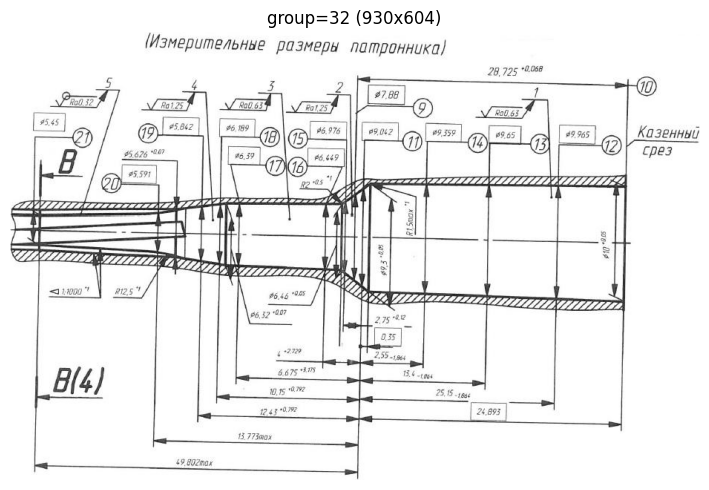

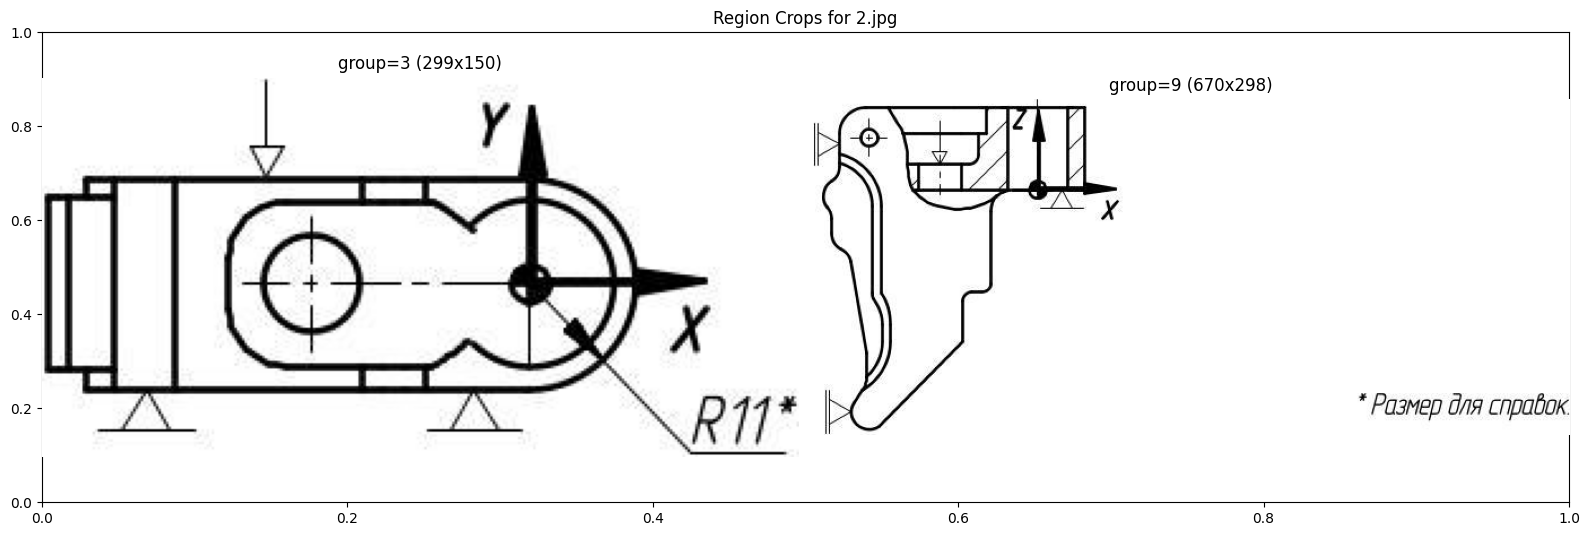

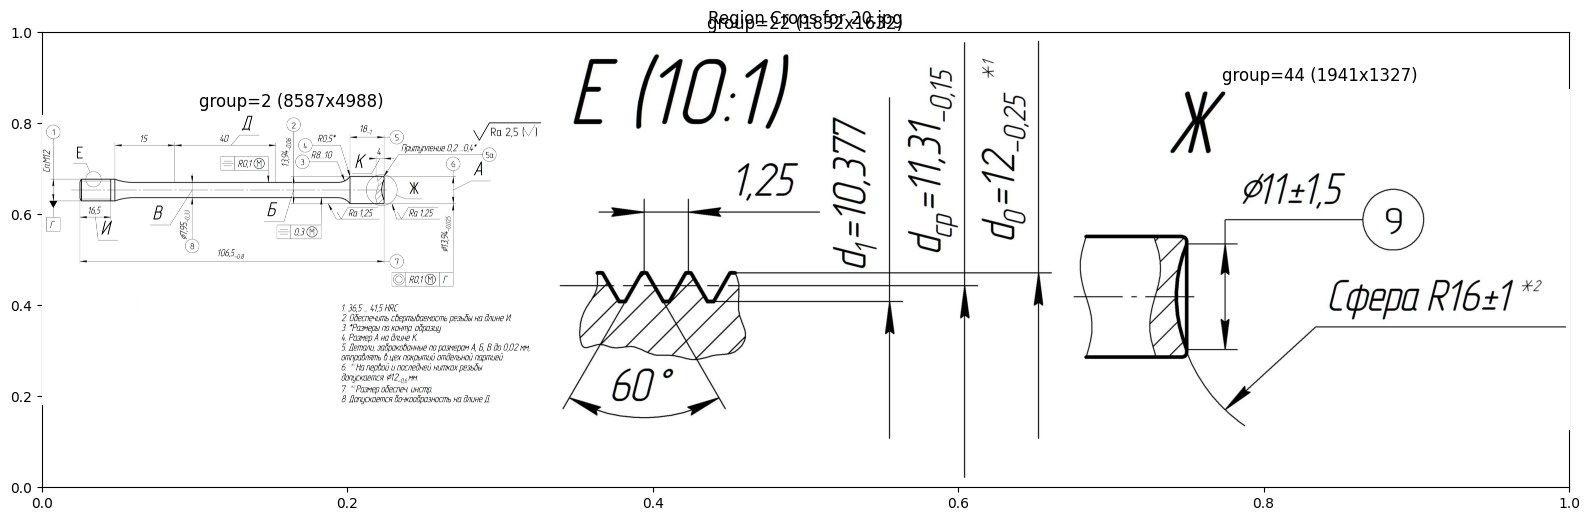

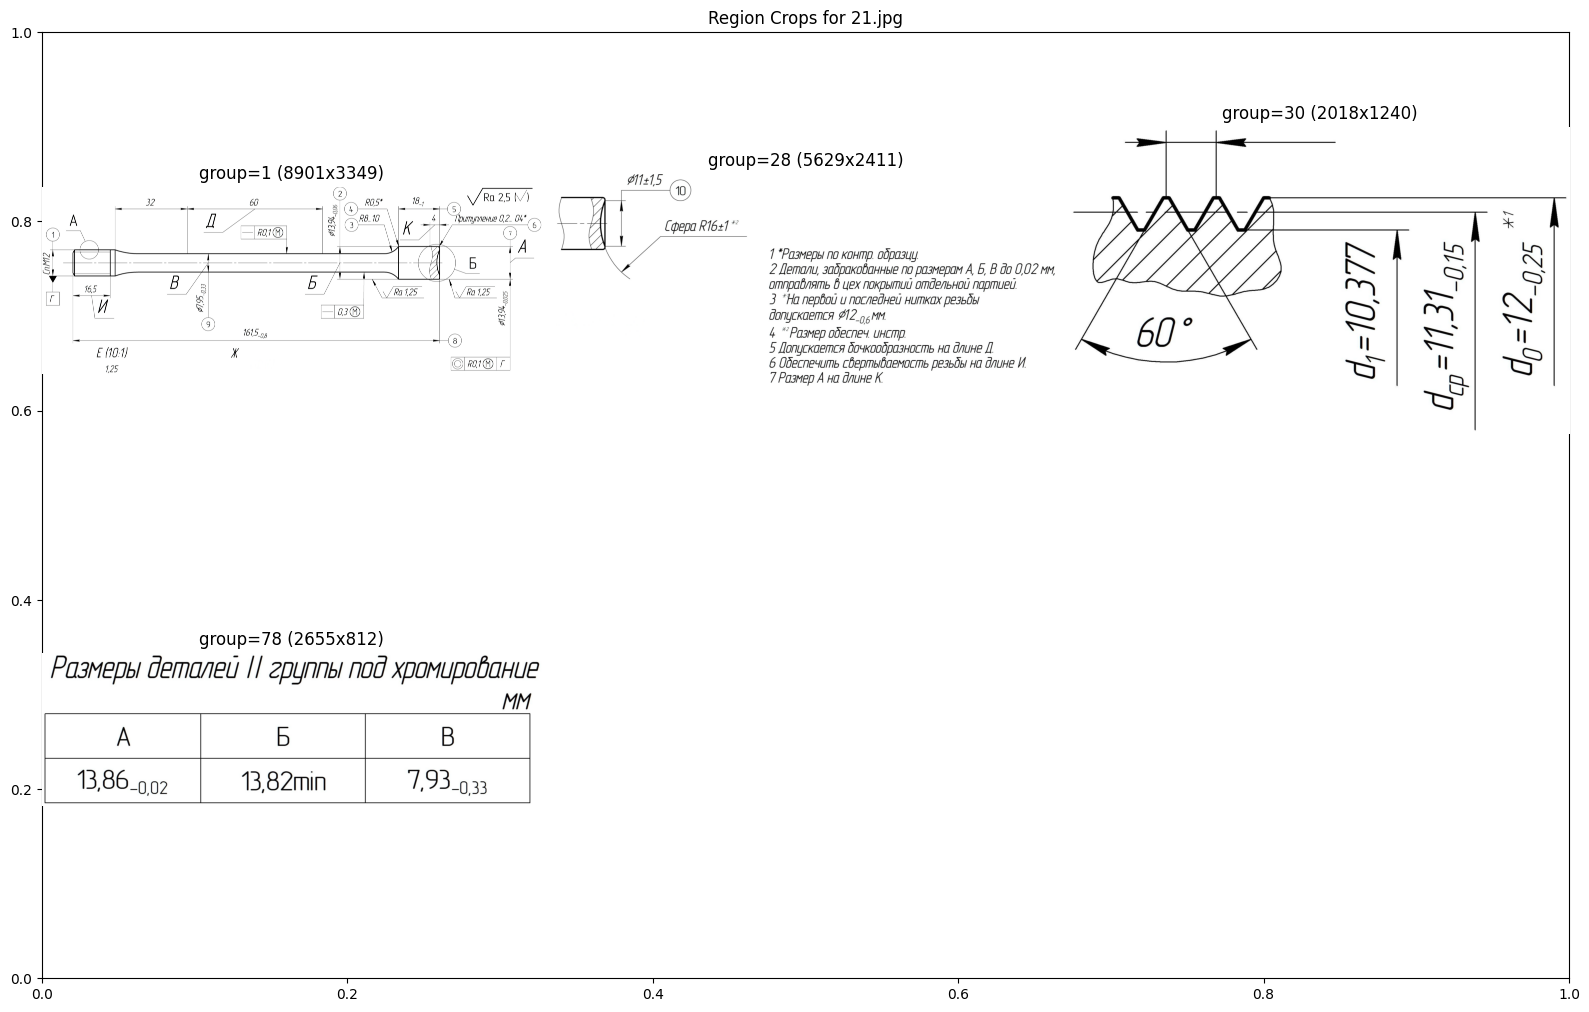

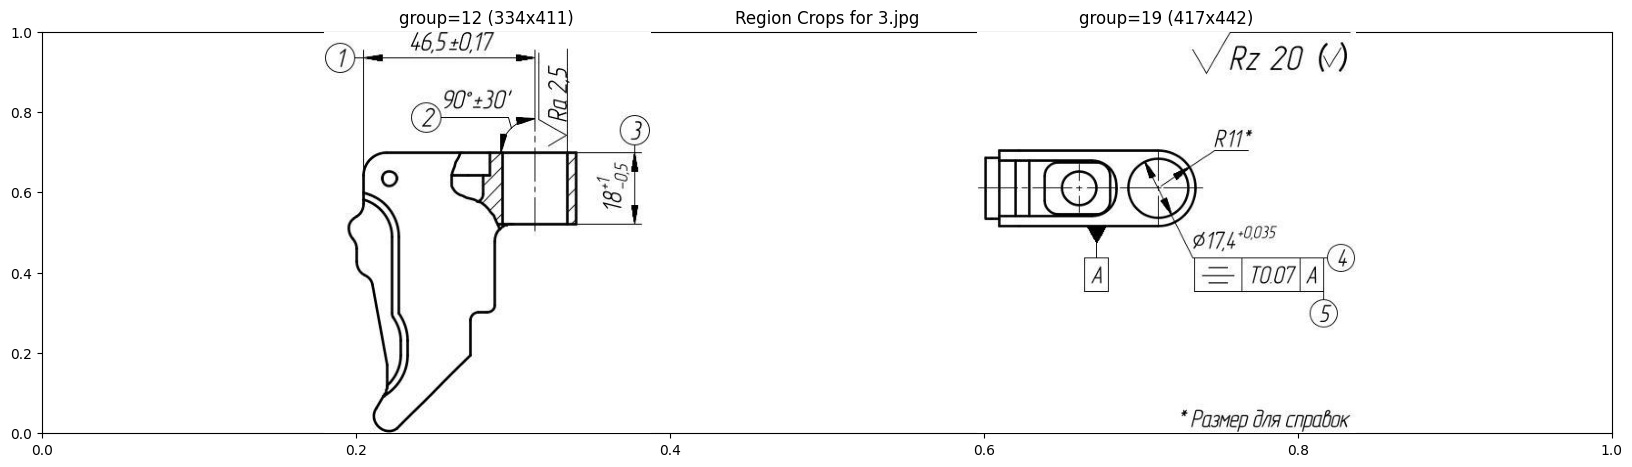

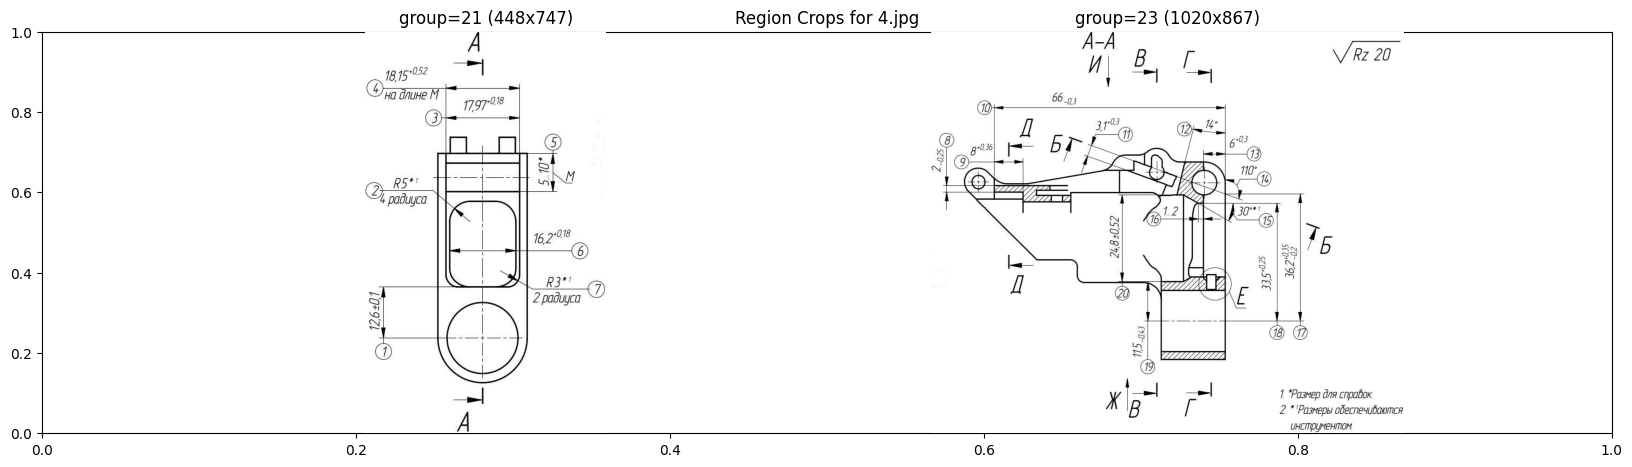

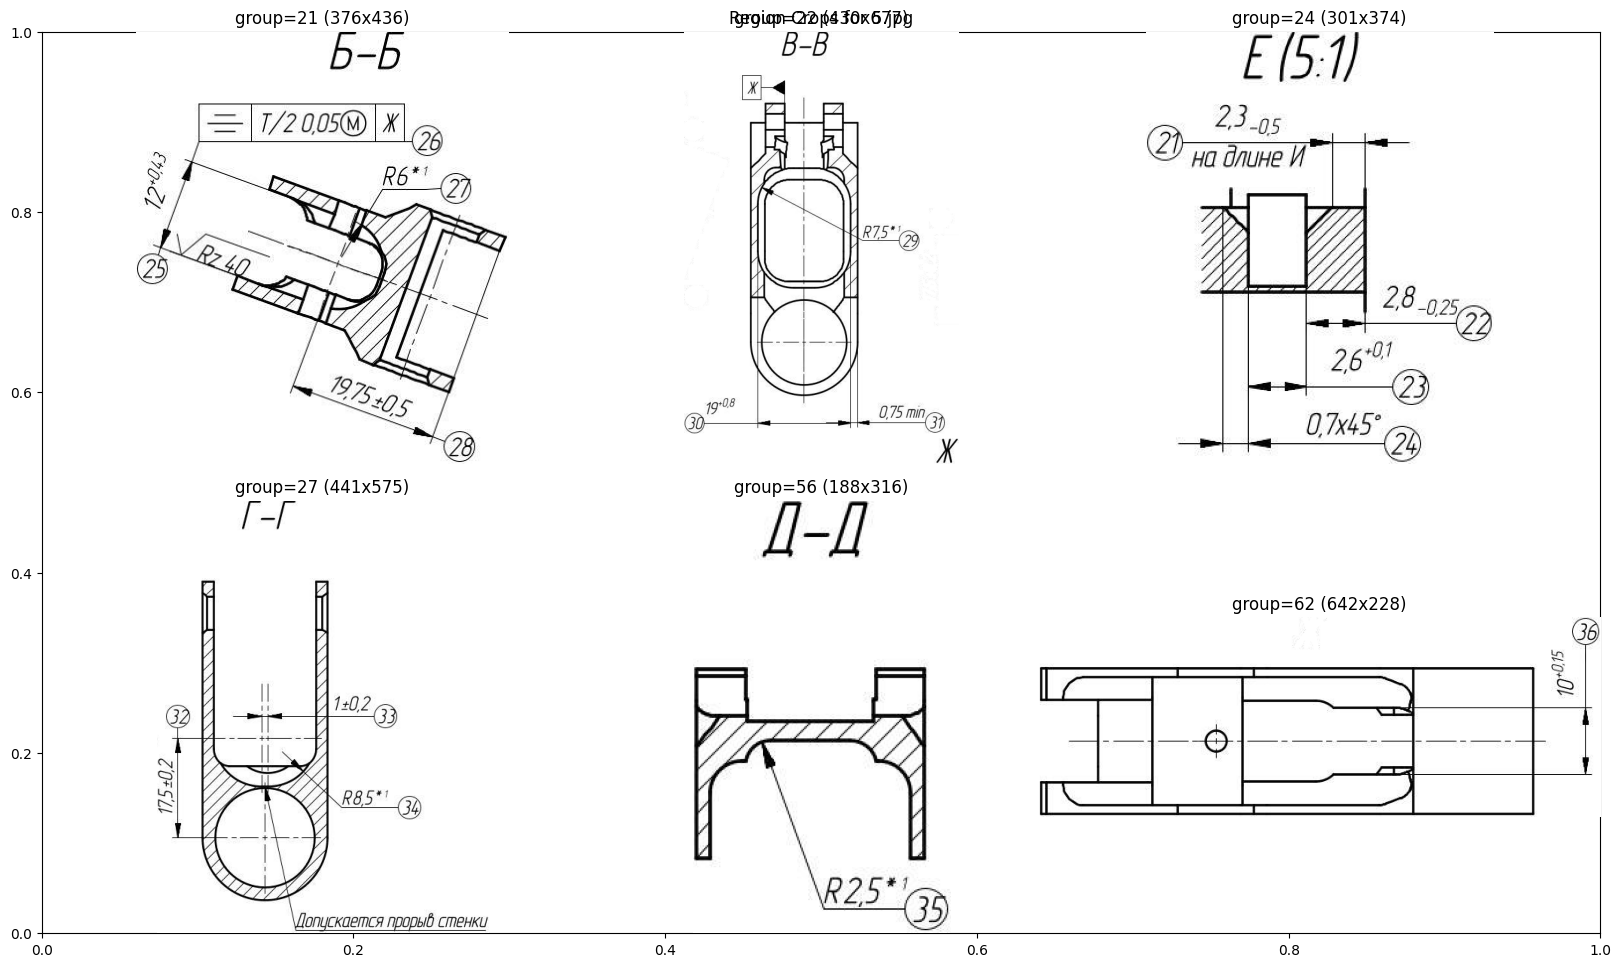

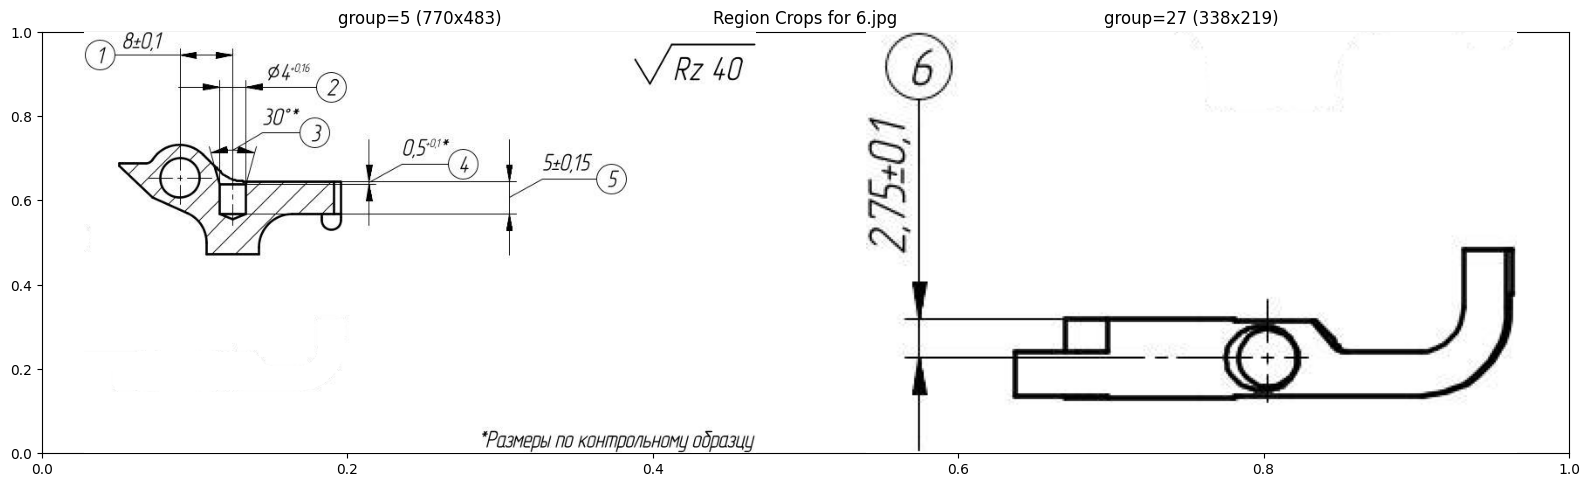

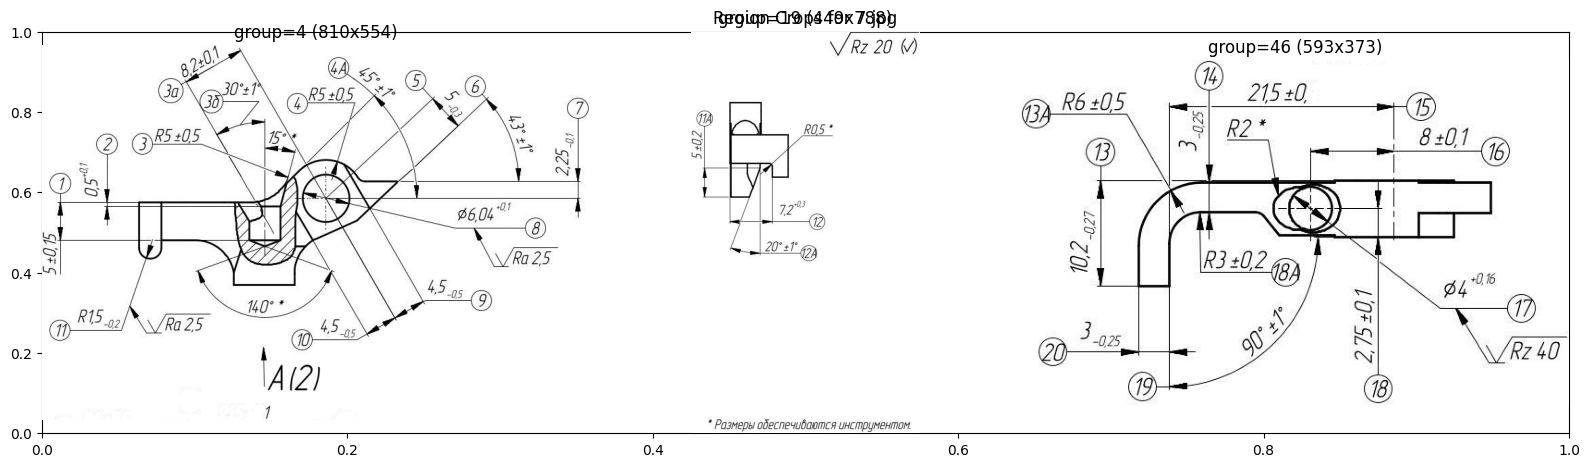

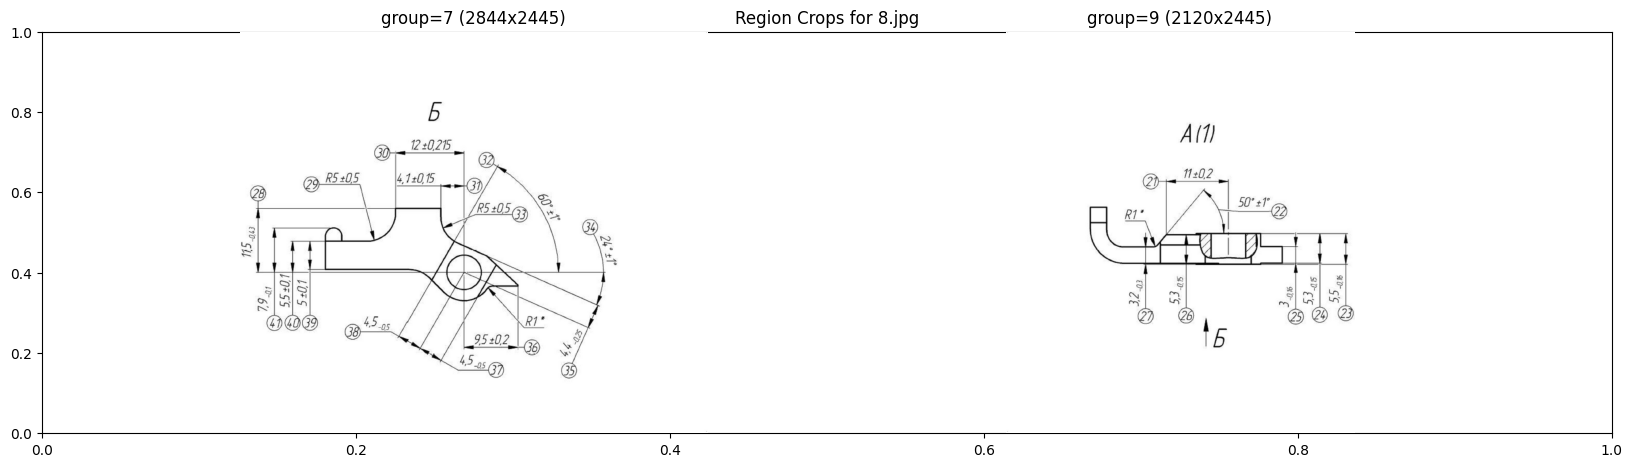

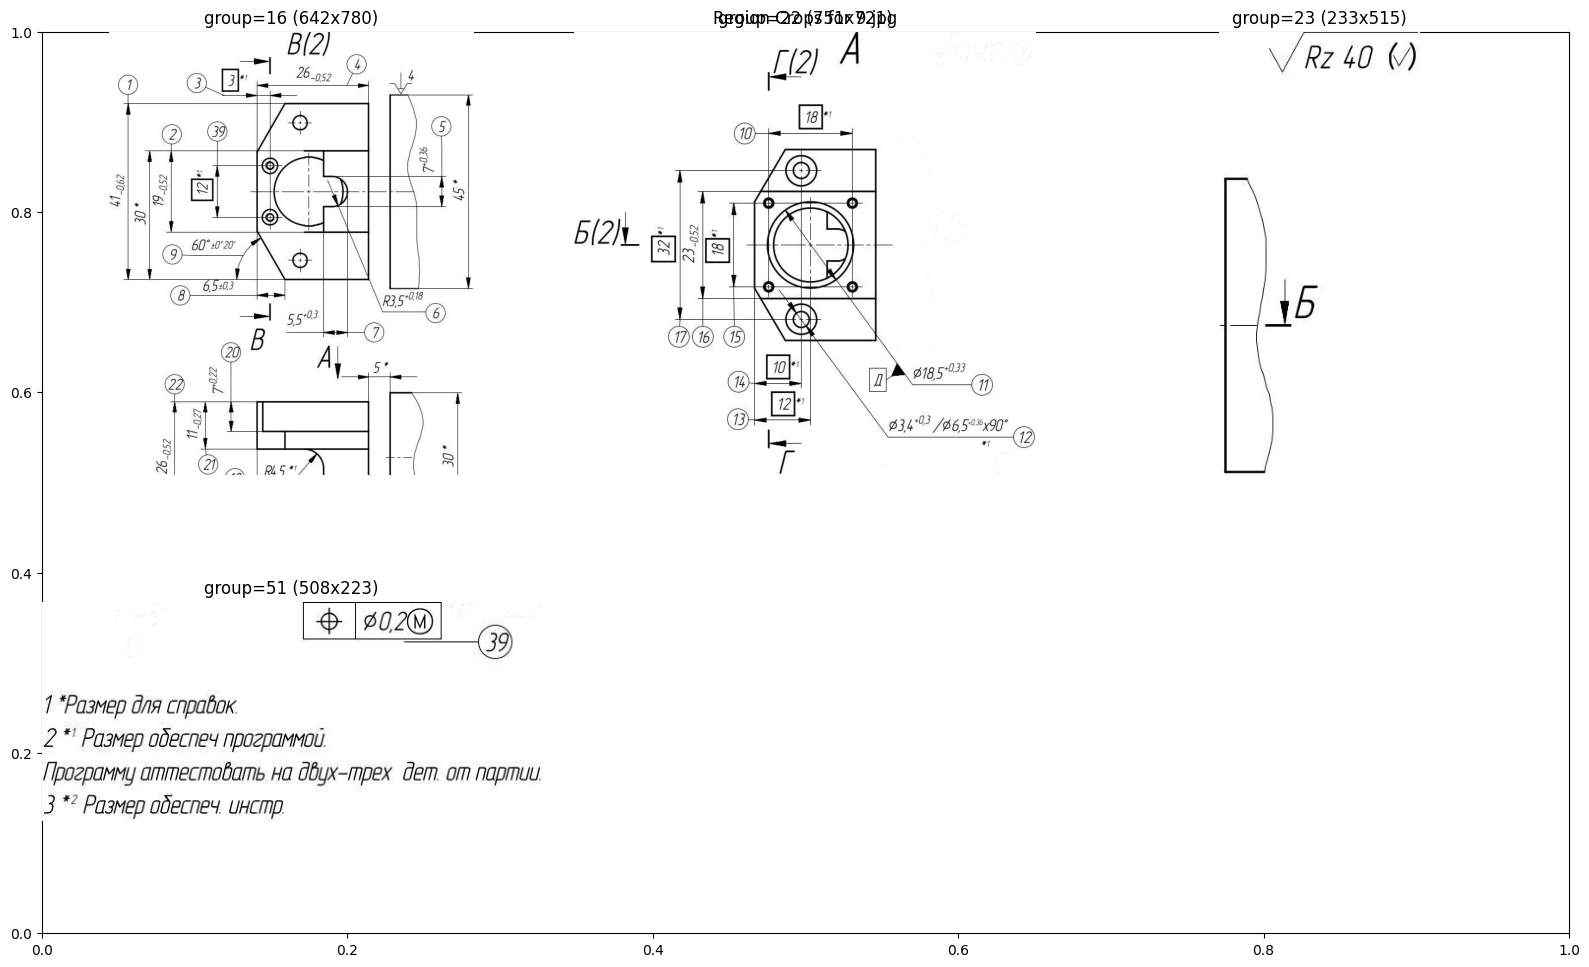

In [3]:
failures: list[tuple[str, Exception]] = []

for file in files:
    image: Mat = load_image(str(file))
    try:
        region_crops: list[RegionCrop] = extract_region_crops(image, run(image))
    except Exception as error:
        failures.append((file.name, error))
        print(f"[{file.name}] FAILED: {error!r}")
        continue
    cols = min(3, len(region_crops))
    rows = (len(region_crops) + cols - 1) // cols
    plt.figure(figsize=(16, 5 * rows))
    plt.title(f"Region Crops for {file.name}")
    for i, crop in enumerate(region_crops):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(crop.image)
        plt.title(f"group={crop.group_label} ({crop.width}x{crop.height})")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


## Пошаговая проверка этапов

In [3]:
file_names = [f.name for f in files]


def _view_img(filename: str):
    path = next(f for f in files if f.name == filename)
    img = load_image(str(path))
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title(img.shape)
    plt.axis("off")
    plt.show()
    return img


ui = widgets.interactive(_view_img, filename=file_names)
display(ui)

interactive(children=(Dropdown(description='filename', options=('1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg…

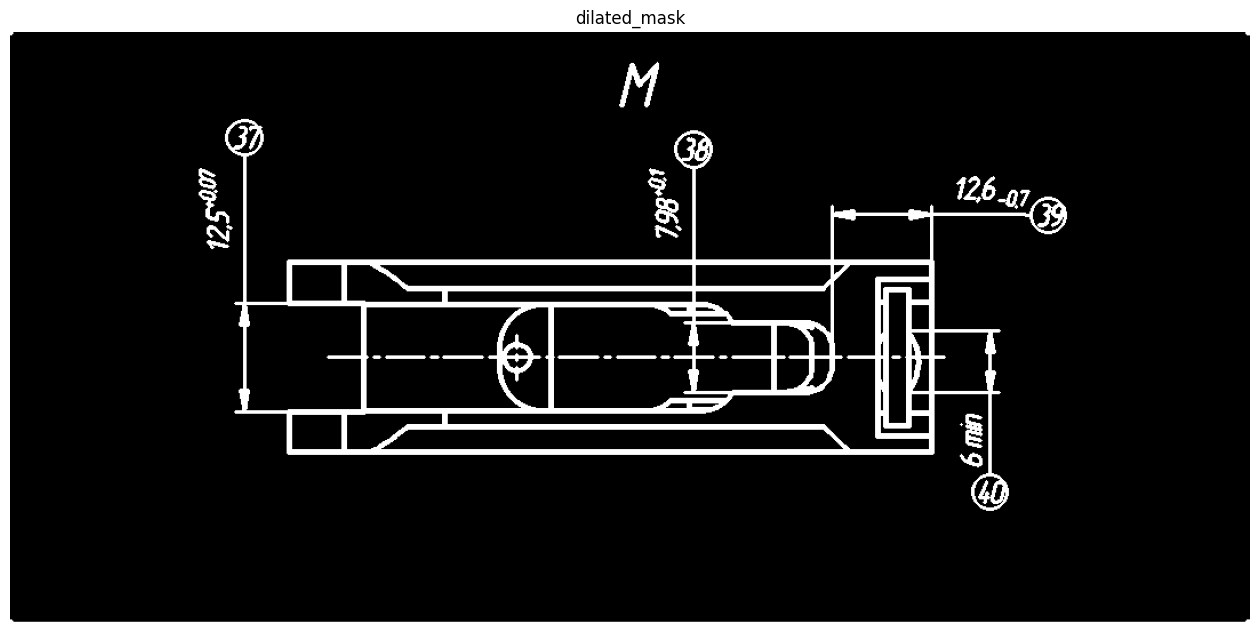

In [4]:
img: Mat = np.array(ui.result, dtype=np.uint8)

dilated_mask = preprocess_drawing(img)

plt.figure(figsize=(16, 8))
plt.imshow(dilated_mask, cmap="gray")
plt.title("dilated_mask")
plt.axis("off")
plt.show()

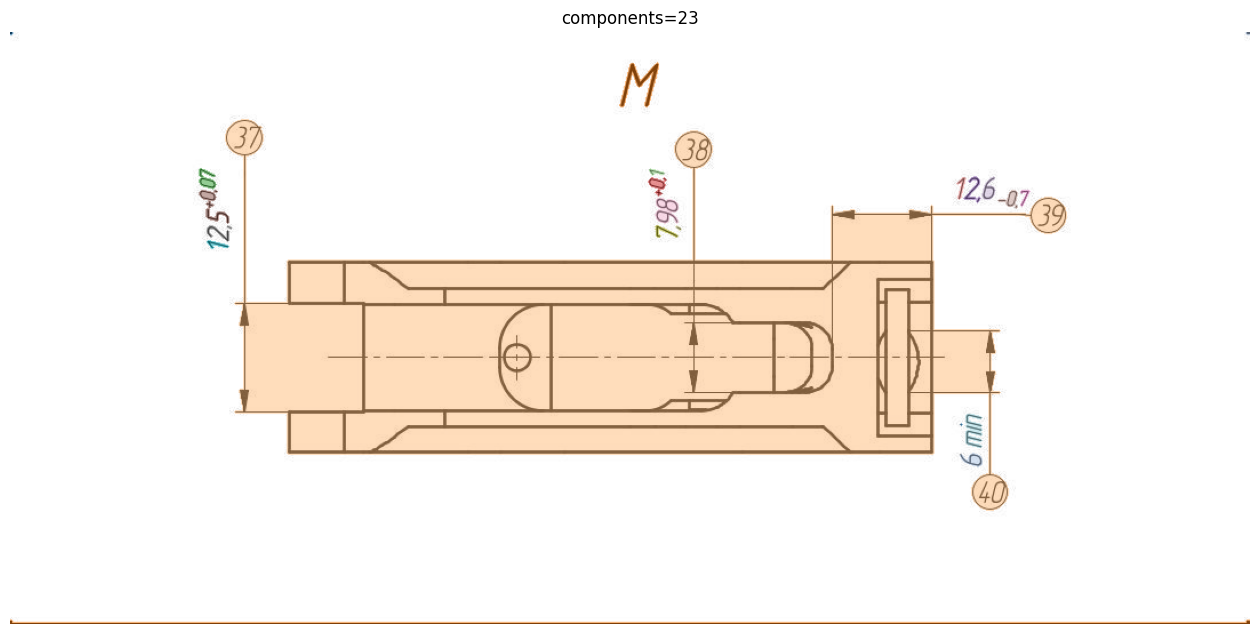

In [5]:
connected_components = find_connected_components(dilated_mask)

cmap = plt.get_cmap("tab20")
vis = img.copy()
for i in range(len(connected_components.area)):
    label = i + 1
    color = np.array(cmap(i % 20)[:3]) * 255
    mask = connected_components.labels == label
    vis[mask] = (vis[mask] * 0.5 + color * 0.5).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(f"components={len(connected_components.area)}")
plt.axis("off")
plt.show()

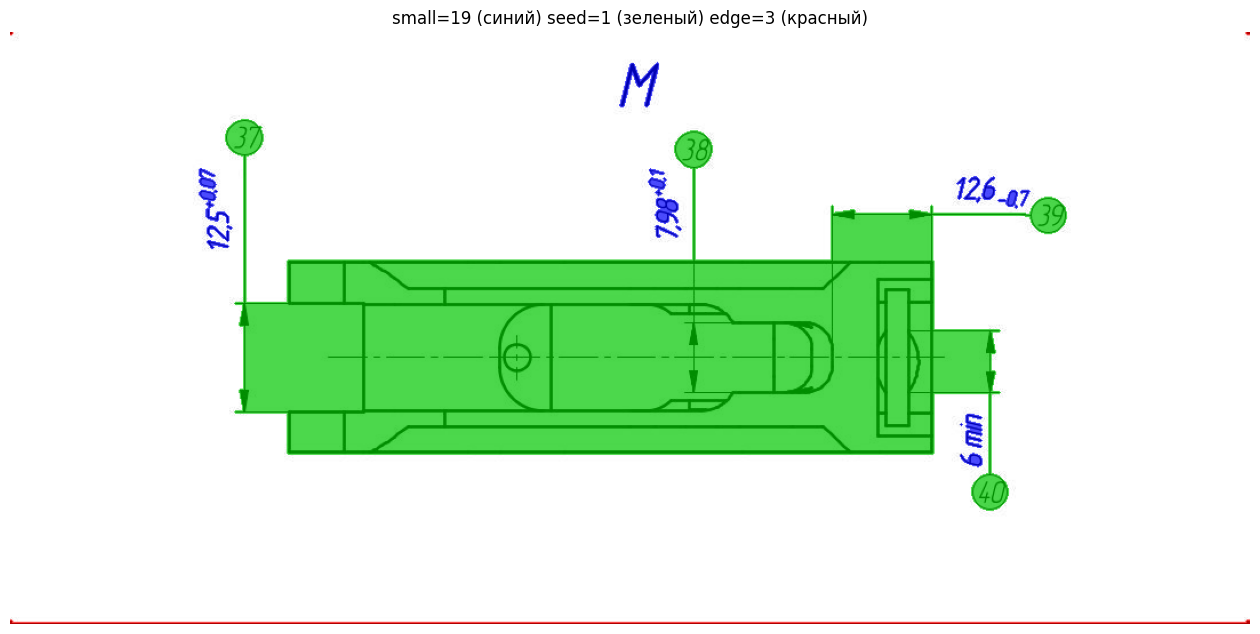

In [6]:
image_height, image_width = img.shape[:2]
classification = classify_components(connected_components, image_height, image_width)

vis = img.copy()
small_mask = np.isin(connected_components.labels, classification.small_labels)
seed_mask = np.isin(connected_components.labels, classification.seed_labels)
edge_mask = np.isin(connected_components.labels, classification.edge_labels)
vis[small_mask] = (vis[small_mask] * 0.3 + np.array([0, 0, 255]) * 0.7).astype(np.uint8)
vis[seed_mask] = (vis[seed_mask] * 0.3 + np.array([0, 200, 0]) * 0.7).astype(np.uint8)
vis[edge_mask] = (vis[edge_mask] * 0.3 + np.array([255, 0, 0]) * 0.7).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(
    f"small={len(classification.small_labels)} (синий) "
    f"seed={len(classification.seed_labels)} (зеленый) "
    f"edge={len(classification.edge_labels)} (красный)"
)
plt.axis("off")
plt.show()

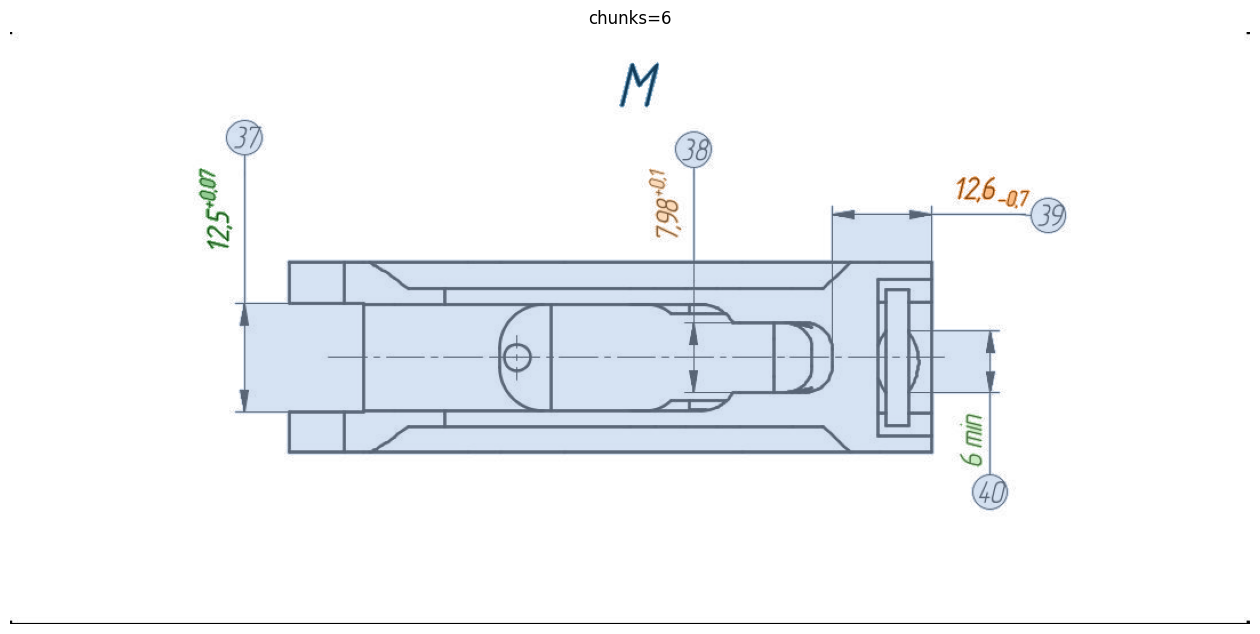

In [7]:
merged_labels = merge_into_chunks(connected_components, classification)

unique_chunks = np.unique(merged_labels)
unique_chunks = unique_chunks[unique_chunks != 0]

cmap = plt.get_cmap("tab20")
vis = img.copy()
for i, chunk in enumerate(unique_chunks):
    color = np.array(cmap(i % 20)[:3]) * 255
    mask = merged_labels == chunk
    vis[mask] = (vis[mask] * 0.5 + color * 0.5).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(f"chunks={len(unique_chunks)}")
plt.axis("off")
plt.show()

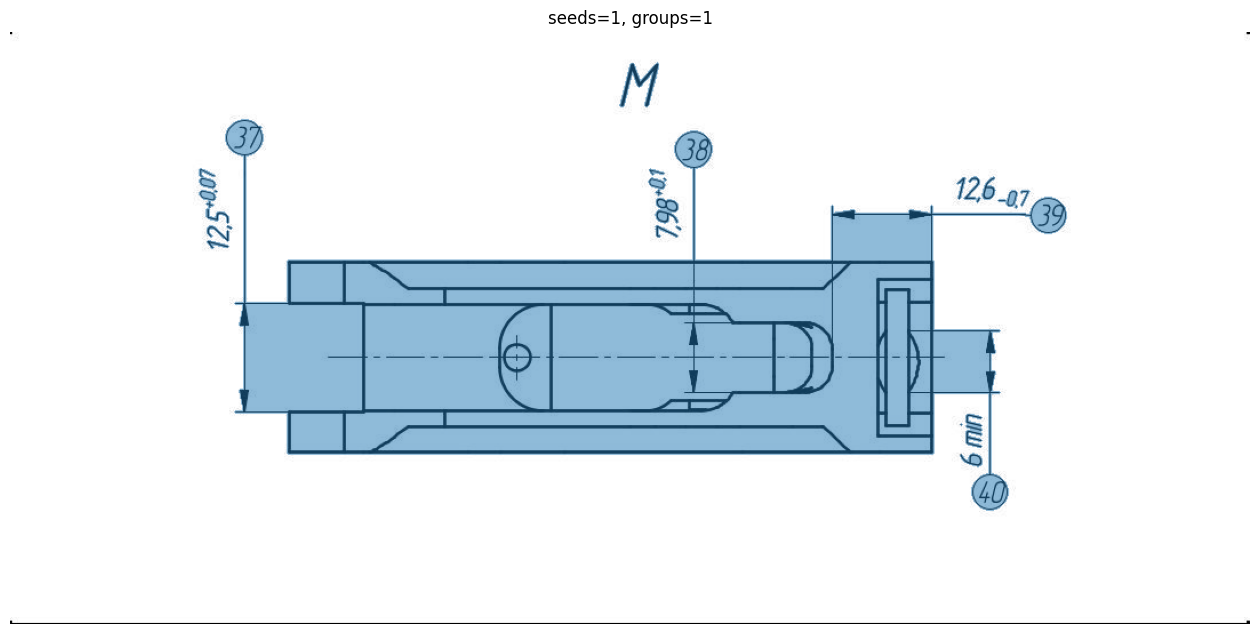

In [8]:
groups = group_regions(connected_components, classification, merged_labels)

unique_groups = np.unique(groups.group_image)
unique_groups = unique_groups[unique_groups != 0]

cmap = plt.get_cmap("tab20")
vis = img.copy()
for i, group in enumerate(unique_groups):
    color = np.array(cmap(i % 20)[:3]) * 255
    mask = groups.group_image == group
    vis[mask] = (vis[mask] * 0.5 + color * 0.5).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(f"seeds={len(classification.seed_labels)}, groups={len(unique_groups)}")
plt.axis("off")
plt.show()